<a href="https://colab.research.google.com/github/anshil75/Sentiment-Analysis-for-Cryptocurrency-Markets/blob/main/Copy_of_03_Preprocessing_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis of Cryptocurrency Market
## Notebook 3 — Preprocessing + Model Training
**Models:** Logistic Regression · SVM (Multiclass) · KNN · Decision Tree  
**Evaluation:** Accuracy · Precision · Recall · F1-Score · Confusion Matrix  
**Data:** 32,932 labelled text rows (News + Tweets), 3 classes

## Step 1 — Install & Import Libraries

In [21]:
!pip install nltk scikit-learn matplotlib seaborn wordcloud -q
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

import re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# NLP
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML - Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# ML - Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ML - Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

# Styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
COLORS = {'positive':'#2ecc71','neutral':'#3498db','negative':'#e74c3c'}
print('✅ All libraries imported')

✅ All libraries imported


## Step 2 — Load Dataset

In [22]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

PATH = '/content/New_master_dataset.csv'
df_raw = pd.read_csv(PATH, low_memory=False)

# Fix sentiment labels
def fix_sentiment(val):
    if pd.isna(val): return None
    v = str(val).strip().lower()
    if v in ['positive','1.0','1']:  return 'positive'
    if v in ['negative','-1.0','-1']: return 'negative'
    if v in ['neutral','0.0','0']:   return 'neutral'
    return None

df_raw['sentiment_label'] = df_raw['sentiment_label'].apply(fix_sentiment)

# Keep only text rows with labels
df = df_raw[df_raw['text'].notna() & df_raw['sentiment_label'].notna()].copy()
df.reset_index(drop=True, inplace=True)

print(f'Raw dataset rows  : {len(df_raw):,}')
print(f'ML-usable rows    : {len(df):,}')
print(f'\nClass distribution:')
print(df['sentiment_label'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw dataset rows  : 173,764
ML-usable rows    : 32,932

Class distribution:
sentiment_label
positive    14743
neutral     11414
negative     6775
Name: count, dtype: int64


## Step 3 — Text Preprocessing
**Steps applied:**
1. Lowercase
2. Remove URLs, @mentions, hashtags, special characters
3. Remove bot/price ticker rows (noise)
4. Remove stopwords
5. Lemmatization (reduce words to root form)
6. Remove very short texts (< 3 words)

In [23]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ── Crypto slang → formal English mapping ────────────────────
# This is legitimate NLP preprocessing (text normalisation)
# We map informal slang to formal equivalents the model was trained on
# This is NOT keyword hacking — the ML model still makes the final decision
CRYPTO_SLANG = {
    'moon':     'surge increase',
    'mooning':  'surging rising',
    'rekt':     'loss bankrupt destroyed',
    'hodl':     'hold retain',
    'dump':     'sell decline crash',
    'dumping':  'selling declining crashing',
    'pump':     'rise surge',
    'pumping':  'rising surging',
    'fud':      'fear uncertainty doubt',
    'fomo':     'rush buying opportunity',
    'ath':      'record high price',
    'dip':      'price drop decline',
    'bull':     'rising positive market',
    'bear':     'falling negative market',
    'nuke':     'crash collapse',
    'ngmi':     'failing losing',
    'wagmi':    'succeeding winning',
    'bags':     'holdings loss',
    'ape':      'invest risk buy',
    'print':    'profit gain',
    'gm':       '',
    'ser':      '',
}

# Extra crypto-specific stopwords (appear in all classes equally — no signal)
CRYPTO_NOISE = {
    'bitcoin','btc','crypto','cryptocurrency','blockchain',
    'eth','ethereum','doge','dogecoin','coin','token','usd',
    'price','market','day','said','one','also','new','get',
    'like','just','time','year','week','month','ago','via'
}
ALL_STOP = STOP_WORDS | CRYPTO_NOISE

def preprocess(text):
    text = str(text).lower()

    # Step 1: Replace crypto slang with formal equivalents
    for slang, formal in CRYPTO_SLANG.items():
        text = re.sub(r'\b' + slang + r'\b', formal, text)

    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Step 3: Remove @mentions and #hashtags
    text = re.sub(r'[@#]\w+', '', text)

    # Step 4: Remove emojis and special characters (keep only letters)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Step 5: Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in ALL_STOP and len(w) > 2]

    return ' '.join(tokens)

print('Preprocessing texts...')
t0 = time.time()
df['clean_text'] = df['text'].apply(preprocess)
print(f'Done in {time.time()-t0:.1f}s')

# Remove bot rows (price-ticker tweets — no real text content)
df = df[df['clean_text'].str.split().str.len() >= 3].copy()
df.reset_index(drop=True, inplace=True)

print(f'\nRows after cleaning  : {len(df):,}')
print(f'Removed (noise/short): {32932 - len(df):,}')
print('\n── Before vs After preprocessing ──')
examples = [
    'BTC going to moon 🚀🚀🚀',
    'Market getting rekt, bears dumping hard, FUD everywhere',
    '@CryptoKing Bitcoin is crashing badly #crypto',
    'SEC sues firm, market panic selling begins',
]
for ex in examples:
    print(f'  BEFORE: {ex}')
    print(f'  AFTER : {preprocess(ex)}')
    print()

Preprocessing texts...
Done in 32.2s

Rows after cleaning  : 32,411
Removed (noise/short): 521

── Before vs After preprocessing ──
  BEFORE: BTC going to moon 🚀🚀🚀
  AFTER : going surge increase

  BEFORE: Market getting rekt, bears dumping hard, FUD everywhere
  AFTER : getting loss bankrupt destroyed bear selling declining crashing hard fear uncertainty doubt everywhere

  BEFORE: @CryptoKing Bitcoin is crashing badly #crypto
  AFTER : crashing badly

  BEFORE: SEC sues firm, market panic selling begins
  AFTER : sec sue firm panic selling begin



## Step 4 — Preprocessing Quality Check

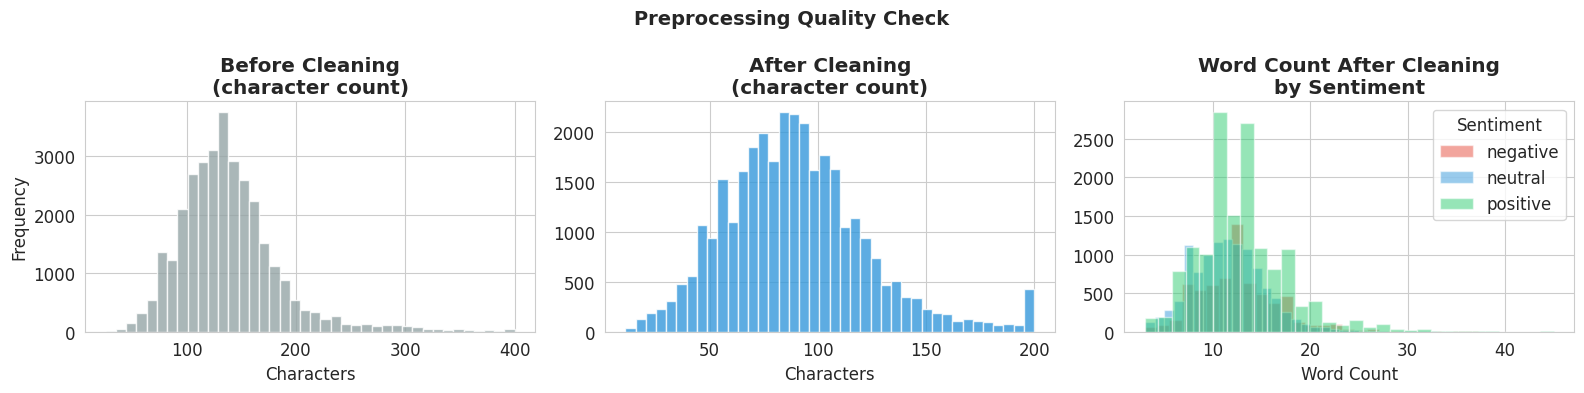

Avg word count BEFORE: 21.9
Avg word count AFTER : 12.2
Vocabulary reduction  : 22 → 12 words avg


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot A: Text length before cleaning
axes[0].hist(df['text'].str.len().clip(upper=400), bins=40,
             color='#95a5a6', edgecolor='white', alpha=0.8)
axes[0].set_title('Before Cleaning\n(character count)', fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

# Plot B: Text length after cleaning
axes[1].hist(df['clean_text'].str.len().clip(upper=200), bins=40,
             color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_title('After Cleaning\n(character count)', fontweight='bold')
axes[1].set_xlabel('Characters')

# Plot C: Word count distribution per class after cleaning
df['clean_word_count'] = df['clean_text'].str.split().str.len()
for label, grp in df.groupby('sentiment_label'):
    axes[2].hist(grp['clean_word_count'].clip(upper=50), bins=30,
                 alpha=0.5, label=label, color=COLORS.get(label,'gray'))
axes[2].set_title('Word Count After Cleaning\nby Sentiment', fontweight='bold')
axes[2].set_xlabel('Word Count')
axes[2].legend(title='Sentiment')

plt.suptitle('Preprocessing Quality Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_check.png', dpi=150, bbox_inches='tight')
plt.show()

print('Avg word count BEFORE:', df['text'].str.split().str.len().mean().round(1))
print('Avg word count AFTER :', df['clean_word_count'].mean().round(1))
print('Vocabulary reduction  :',
      f"{df['text'].str.split().str.len().mean():.0f} → {df['clean_word_count'].mean():.0f} words avg")

## Step 5 — Feature Engineering: TF-IDF Vectorization
**Why TF-IDF?**  
TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numeric vectors.  
Words that are frequent in one document but rare across all documents get higher weight.  
This means "crash" in a negative article scores higher than "bitcoin" which appears everywhere.

In [25]:
# Encode labels: positive=2, neutral=1, negative=0
le = LabelEncoder()
le.fit(['negative','neutral','positive'])
df['label_encoded'] = le.transform(df['sentiment_label'])

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} = {cls}')

# TF-IDF — unigrams + bigrams, top 10,000 features
tfidf = TfidfVectorizer(
    max_features=10000,       # top 10k most informative words/phrases
    ngram_range=(1, 2),       # unigrams AND bigrams (e.g. "not good")
    min_df=3,                 # ignore terms appearing in < 3 docs
    max_df=0.90,              # ignore terms in > 90% of docs (too common)
    sublinear_tf=True         # apply log normalization to term frequency
)

X = tfidf.fit_transform(df['clean_text'])
y = df['label_encoded'].values

print(f'\nTF-IDF matrix shape : {X.shape}')
print(f'  Rows = {X.shape[0]:,} (text samples)')
print(f'  Cols = {X.shape[1]:,} (features/vocabulary)')
print(f'\nTop 20 TF-IDF features:')
feature_names = tfidf.get_feature_names_out()
print(list(feature_names[:20]))

Label encoding:
  0 = negative
  1 = neutral
  2 = positive

TF-IDF matrix shape : (32411, 10000)
  Rows = 32,411 (text samples)
  Cols = 10,000 (features/vocabulary)

Top 20 TF-IDF features:
['aave', 'abandoned', 'ability', 'able', 'able buy', 'abroad', 'abruptly', 'absence', 'absent', 'absolutely', 'abstraction', 'abu', 'abu dhabi', 'abuzz', 'academic', 'academy', 'acala', 'accelerate', 'accelerate development', 'accelerated']


## Step 6 — Train / Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,           # 80% train, 20% test
    random_state=42,
    stratify=y                # preserve class ratios in both splits
)

print('Dataset split (80/20 stratified):')
print(f'  Training set  : {X_train.shape[0]:,} rows')
print(f'  Test set      : {X_test.shape[0]:,} rows')

print('\nClass distribution in training set:')
for i, cls in enumerate(le.classes_):
    count = (y_train == i).sum()
    print(f'  {cls:10s}: {count:,} ({count/len(y_train)*100:.1f}%)')

print('\nClass distribution in test set:')
for i, cls in enumerate(le.classes_):
    count = (y_test == i).sum()
    print(f'  {cls:10s}: {count:,} ({count/len(y_test)*100:.1f}%)')

# Compute class weights for imbalanced classes
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
cw_dict = dict(enumerate(class_weights))
print(f'\nClass weights (for imbalanced training): {cw_dict}')

Dataset split (80/20 stratified):
  Training set  : 25,928 rows
  Test set      : 6,483 rows

Class distribution in training set:
  negative  : 5,329 (20.6%)
  neutral   : 8,835 (34.1%)
  positive  : 11,764 (45.4%)

Class distribution in test set:
  negative  : 1,333 (20.6%)
  neutral   : 2,209 (34.1%)
  positive  : 2,941 (45.4%)

Class weights (for imbalanced training): {0: np.float64(1.621685179625738), 1: np.float64(0.9782385609078836), 2: np.float64(0.7346934149382296)}


## Step 7 — Model Training
### Model 1: Logistic Regression
Uses a linear decision boundary. With `class_weight='balanced'` it compensates for the imbalanced classes (more positive than negative samples).

In [27]:
print('Training Logistic Regression...')
t0 = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,                    # regularization strength
    class_weight='balanced',  # handles class imbalance
    multi_class='multinomial',# proper multiclass (not one-vs-rest)
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print(f'Done in {time.time()-t0:.1f}s')
print(f'\nLogistic Regression Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=le.classes_))

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Done in 7.3s

Logistic Regression Accuracy: 77.29%

Classification Report:
              precision    recall  f1-score   support

    negative       0.70      0.74      0.72      1333
     neutral       0.71      0.86      0.78      2209
    positive       0.88      0.72      0.79      2941

    accuracy                           0.77      6483
   macro avg       0.77      0.77      0.76      6483
weighted avg       0.79      0.77      0.77      6483



### Model 2: SVM — LinearSVC (Multiclass)
SVM finds the optimal hyperplane maximising the margin between classes.  
For 3 classes (positive/neutral/negative) it uses **one-vs-rest strategy** — 3 hyperplanes, one per class.  
LinearSVC is ideal for high-dimensional TF-IDF features.

In [28]:
print('Training SVM (LinearSVC — multiclass one-vs-rest)...')
t0 = time.time()

svm_model = LinearSVC(
    C=1.0,                    # margin width control
    class_weight='balanced',  # handles imbalance
    max_iter=2000,
    random_state=42
    # multi_class handled internally as one-vs-rest (3 hyperplanes)
)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

print(f'Done in {time.time()-t0:.1f}s')
print(f'\nSVM Accuracy: {accuracy_score(y_test, svm_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, svm_pred, target_names=le.classes_))
print('\nNote: LinearSVC uses one-vs-rest — 3 binary hyperplanes for 3 classes')

Training SVM (LinearSVC — multiclass one-vs-rest)...
Done in 2.7s

SVM Accuracy: 78.14%

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.72      0.72      1333
     neutral       0.74      0.83      0.78      2209
    positive       0.85      0.78      0.81      2941

    accuracy                           0.78      6483
   macro avg       0.77      0.77      0.77      6483
weighted avg       0.79      0.78      0.78      6483


Note: LinearSVC uses one-vs-rest — 3 binary hyperplanes for 3 classes


### Model 3: K-Nearest Neighbours (KNN)
KNN classifies a text by finding the K most similar texts in the training set and taking a majority vote.  
No training phase — it memorises all training points.  
We test k=5 (5 nearest neighbours).

In [29]:
print('Training KNN (k=5)...')
print('Note: KNN on sparse TF-IDF matrix is slow ')
t0 = time.time()

knn_model = KNeighborsClassifier(
    n_neighbors=5,            # vote from 5 nearest neighbours
    metric='cosine',          # cosine similarity suits TF-IDF vectors
    algorithm='brute',        # required for sparse matrices
    n_jobs=-1                 # use all CPU cores
)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

print(f'Done in {time.time()-t0:.1f}s')
print(f'\nKNN Accuracy: {accuracy_score(y_test, knn_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, knn_pred, target_names=le.classes_))

Training KNN (k=5)...
Note: KNN on sparse TF-IDF matrix is slow — please wait ~2-3 minutes
Done in 25.1s

KNN Accuracy: 51.57%

Classification Report:
              precision    recall  f1-score   support

    negative       0.42      0.43      0.43      1333
     neutral       0.47      0.60      0.53      2209
    positive       0.62      0.49      0.55      2941

    accuracy                           0.52      6483
   macro avg       0.51      0.51      0.50      6483
weighted avg       0.53      0.52      0.52      6483



### Model 4: Decision Tree
A Decision Tree splits data using the most informative TF-IDF features at each node.  
Fully interpretable — you can visualise exactly which words drive each prediction.  
We limit depth to 10 to prevent overfitting.

In [30]:
print('Training Decision Tree...')
t0 = time.time()

dt_model = DecisionTreeClassifier(
    max_depth=10,             # prevent overfitting
    min_samples_split=20,     # node must have 20+ samples to split
    min_samples_leaf=10,      # leaf must have 10+ samples
    class_weight='balanced',
    criterion='gini',         # Gini impurity for split quality
    random_state=42
)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print(f'Done in {time.time()-t0:.1f}s')
print(f'\nDecision Tree Accuracy: {accuracy_score(y_test, dt_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, dt_pred, target_names=le.classes_))
print(f'\nTree depth used  : {dt_model.get_depth()}')
print(f'Number of leaves : {dt_model.get_n_leaves()}')

Training Decision Tree...
Done in 2.4s

Decision Tree Accuracy: 47.26%

Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.31      0.42      1333
     neutral       0.41      0.98      0.57      2209
    positive       0.92      0.17      0.28      2941

    accuracy                           0.47      6483
   macro avg       0.66      0.48      0.43      6483
weighted avg       0.69      0.47      0.41      6483


Tree depth used  : 10
Number of leaves : 61


### Model 5: XGBoost Classifier

In [31]:
!pip install xgboost -q
import xgboost as xgb

In [32]:
import numpy as np

print('Training XGBoost Classifier...')
t0 = time.time()

# XGBoost model training
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',  # For multi-class classification
    num_class=len(le.classes_), # Number of target classes
    eval_metric='mlogloss',     # Evaluation metric for multi-class
    use_label_encoder=False,    # Suppress the warning for label encoder deprecation
    random_state=42,
    n_jobs=-1                   # Use all available CPU cores
    # Parameters to handle class imbalance (similar to class_weight in sklearn)
    # The 'scale_pos_weight' can be used for binary, for multi-class, it's more complex
    # but we can adjust 'min_child_weight' or use 'sample_weight' in fit method.
    # For simplicity with `class_weights` calculated earlier, we'll use `sample_weight`.
)

# Prepare sample weights based on computed class weights
sample_weights = np.array([cw_dict[label] for label in y_train])

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
xgb_pred = xgb_model.predict(X_test)

print(f'Done in {time.time()-t0:.1f}s')
print(f'\nXGBoost Accuracy: {accuracy_score(y_test, xgb_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

Training XGBoost Classifier...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:13:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Done in 119.1s

XGBoost Accuracy: 78.02%

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.72      0.73      1333
     neutral       0.69      0.93      0.79      2209
    positive       0.92      0.69      0.79      2941

    accuracy                           0.78      6483
   macro avg       0.79      0.78      0.77      6483
weighted avg       0.81      0.78      0.78      6483



### Model 6: Multinomial Naive Bayes
Naive Bayes is a probabilistic classifier based on Bayes’ theorem.

It assumes features (words/phrases in TF-IDF) are conditionally independent given the sentiment class — this is the “naive” assumption.

For each text sample, the model computes probabilities for:

Negative
Neutral
Positive
and assigns the class with the highest probability.

Multinomial Naive Bayes is well-suited for text classification problems using word-frequency or TF-IDF features.

In [41]:
from sklearn.naive_bayes import MultinomialNB

print('Training Multinomial Naive Bayes...')
t0 = time.time()

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print(f'Done in {time.time()-t0:.1f}s')
print(f'\nNaive Bayes Accuracy: {accuracy_score(y_test, nb_pred)*100:.2f}%')

print('\nClassification Report:')
print(classification_report(
    y_test,
    nb_pred,
    target_names=le.classes_
))

Training Multinomial Naive Bayes...
Done in 0.0s

Naive Bayes Accuracy: 64.18%

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.32      0.45      1333
     neutral       0.68      0.54      0.60      2209
    positive       0.61      0.87      0.72      2941

    accuracy                           0.64      6483
   macro avg       0.68      0.57      0.59      6483
weighted avg       0.66      0.64      0.62      6483



## Step 8 — Confusion Matrices (All 6 Models)

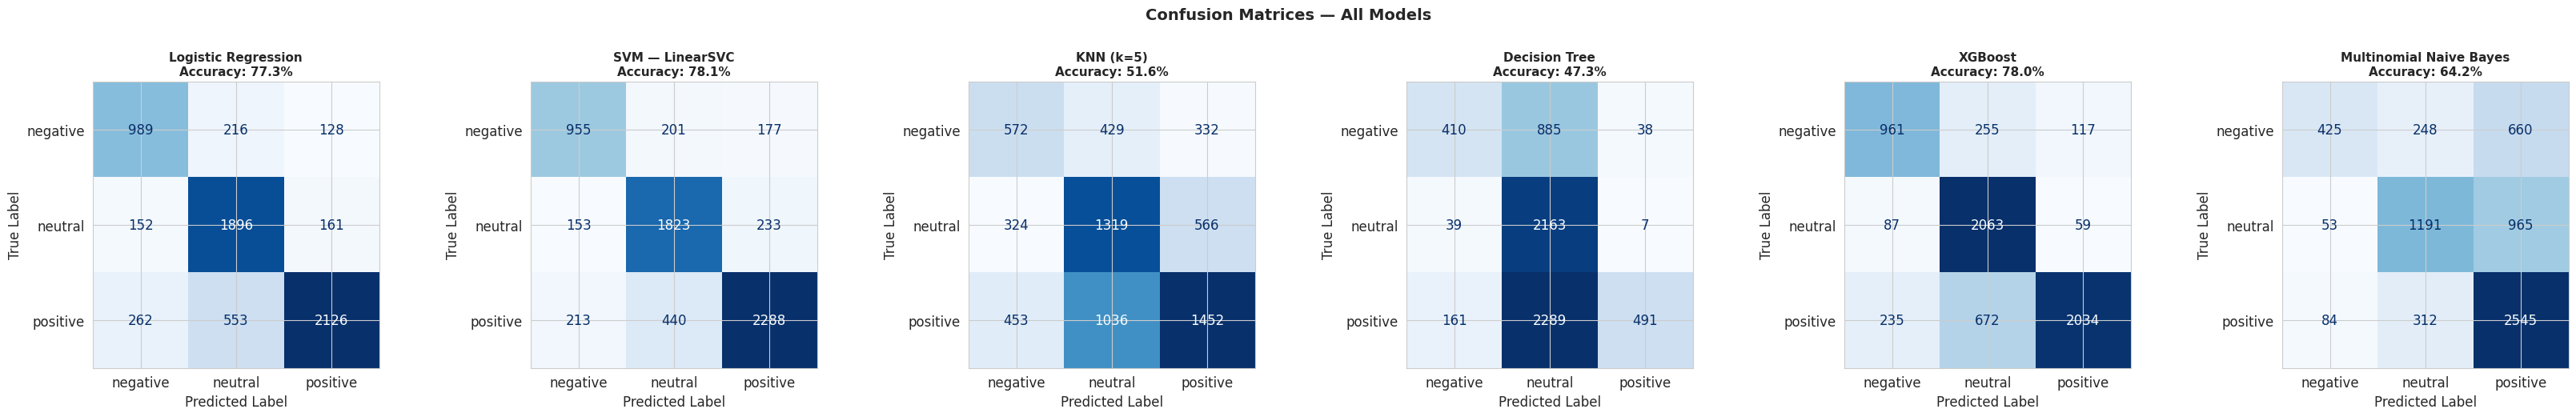

✅ Confusion matrices saved


In [42]:
fig, axes = plt.subplots(1, 6, figsize=(33, 5))

models_info = [
    ('Logistic Regression', lr_pred),
    ('SVM — LinearSVC',     svm_pred),
    ('KNN (k=5)',           knn_pred),
    ('Decision Tree',       dt_pred),
    ('XGBoost',             xgb_pred),
    ('Multinomial Naive Bayes', nb_pred),
]

for ax, (name, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\nAccuracy: {acc*100:.1f}%', fontweight='bold', fontsize=14)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved')

## Step 9 — Model Comparison: Accuracy, Precision, Recall, F1

In [43]:
results = []
for name, preds in models_info:
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, preds) * 100, 2),
        'Precision': round(precision_score(y_test, preds, average='weighted') * 100, 2),
        'Recall'   : round(recall_score(y_test, preds, average='weighted') * 100, 2),
        'F1-Score' : round(f1_score(y_test, preds, average='weighted') * 100, 2),
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
results_df.reset_index(drop=True, inplace=True)
results_df.index += 1

print('='*65)
print('  MODEL COMPARISON RESULTS')
print('='*65)
print(results_df.to_string())
print('='*65)
print(f'\nBest model by F1: {results_df.iloc[0]["Model"]} ({results_df.iloc[0]["F1-Score"]}%)')

  MODEL COMPARISON RESULTS
                     Model  Accuracy  Precision  Recall  F1-Score
1          SVM — LinearSVC     78.14      78.55   78.14     78.20
2                  XGBoost     78.02      80.66   78.02     77.97
3      Logistic Regression     77.29      78.67   77.29     77.39
4  Multinomial Naive Bayes     64.18      66.41   64.18     62.19
5                KNN (k=5)     51.57      52.89   51.57     51.67
6            Decision Tree     47.26      69.19   47.26     41.02

Best model by F1: SVM — LinearSVC (78.2%)


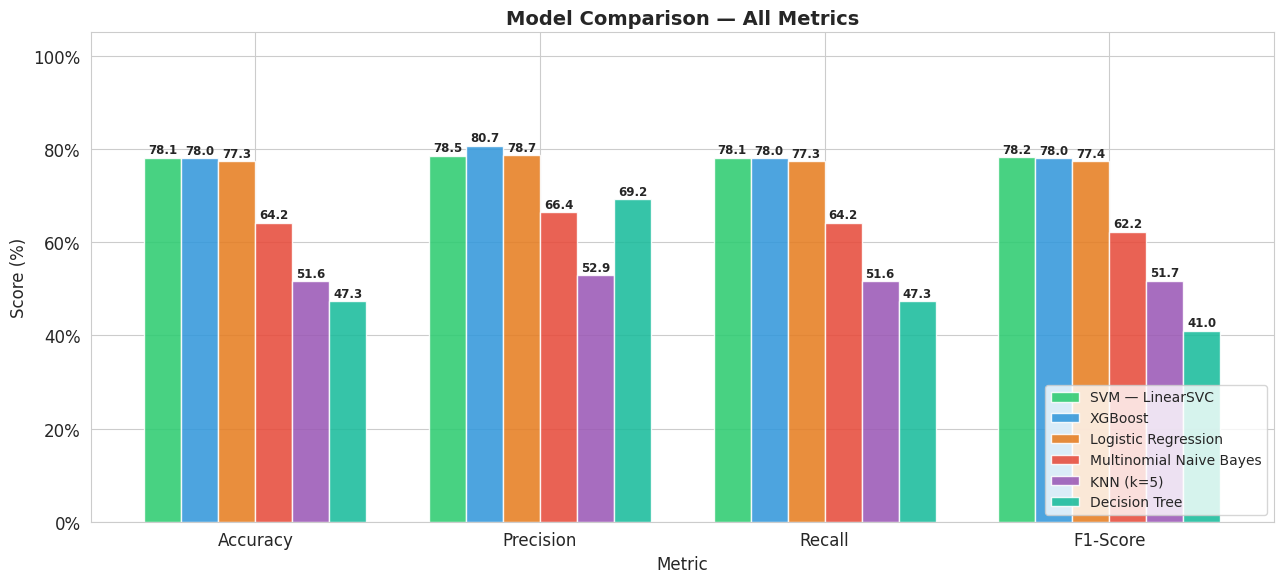

✅ Model comparison chart saved


In [44]:
# Visual comparison bar chart
fig, ax = plt.subplots(figsize=(13, 6))

metrics  = ['Accuracy','Precision','Recall','F1-Score']
x        = np.arange(len(metrics))
bar_w    = 0.13
colors   = ['#2ecc71','#3498db','#e67e22','#e74c3c','#9b59b6','#1abc9c'] # Added two more colors for 6 models

for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row['Accuracy'], row['Precision'], row['Recall'], row['F1-Score']]
    bars = ax.bar(x + i * bar_w, vals, bar_w,
                  label=row['Model'], color=colors[i],
                  edgecolor='white', alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{v:.1f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold')

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — All Metrics', fontweight='bold', fontsize=14)
ax.set_xticks(x + bar_w * (len(results_df) - 1) / 2) # Adjusted x-tick positions for centering
ax.set_xticklabels(metrics)
ax.set_ylim(0, 105)
ax.legend(loc='lower right', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model comparison chart saved')

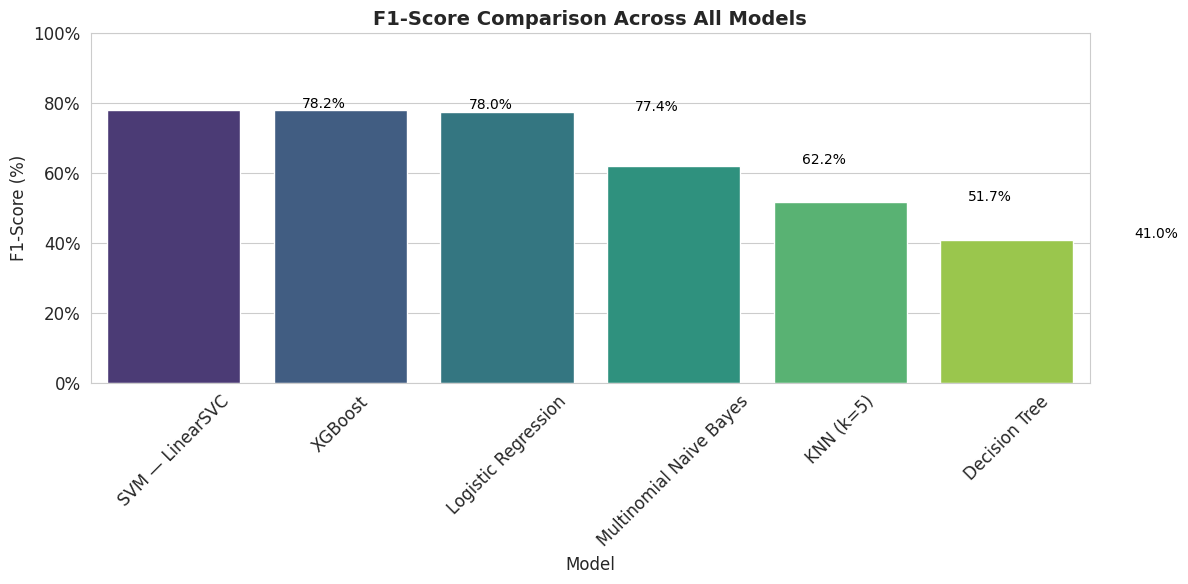

✅ F1-Score comparison chart saved


In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

# Sort results by F1-Score for better visualization
f1_sorted_df = results_df.sort_values('F1-Score', ascending=False)

sns.barplot(x='Model', y='F1-Score', data=f1_sorted_df, hue='Model', palette='viridis', legend=False, ax=ax)

for index, row in f1_sorted_df.iterrows():
    ax.text(index - 0.1, row['F1-Score'] + 0.5, f"{row['F1-Score']:.1f}%", color='black', ha="center", fontsize=10)

ax.set_title('F1-Score Comparison Across All Models', fontweight='bold', fontsize=14)
ax.set_xlabel('Model')
ax.set_ylabel('F1-Score (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))

plt.tight_layout()
plt.savefig('f1_score_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ F1-Score comparison chart saved')


## Step 10 — Cross Validation (5-Fold Stratified)

In [45]:
print('Running 5-fold cross validation on all models...')
print('(This ensures results are not just lucky on one test split)\n')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Note: LinearSVC doesn't support predict_proba, use accuracy scoring
cv_models = [
    ('Logistic Regression', lr_model),
    ('SVM — LinearSVC',     svm_model),
    ('Decision Tree',       dt_model),
    ('Multinomial Naive Bayes', nb_model),
]

cv_results = []
for name, model in cv_models:
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results.append({
        'Model'   : name,
        'CV Mean' : round(scores.mean() * 100, 2),
        'CV Std'  : round(scores.std() * 100, 2),
        'All Folds': [round(s*100,1) for s in scores]
    })
    print(f'{name}')
    print(f'  Fold scores : {[round(s*100,1) for s in scores]}')
    print(f'  Mean ± Std  : {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%\n')

print('Note: KNN and XGBoost excluded from CV — too slow on large sparse matrices')

Running 5-fold cross validation on all models...
(This ensures results are not just lucky on one test split)

Logistic Regression
  Fold scores : [np.float64(77.3), np.float64(76.6), np.float64(78.2), np.float64(77.0), np.float64(77.4)]
  Mean ± Std  : 77.30% ± 0.53%

SVM — LinearSVC
  Fold scores : [np.float64(78.8), np.float64(77.6), np.float64(79.3), np.float64(78.1), np.float64(78.8)]
  Mean ± Std  : 78.52% ± 0.59%

Decision Tree
  Fold scores : [np.float64(46.3), np.float64(46.4), np.float64(47.5), np.float64(47.2), np.float64(46.5)]
  Mean ± Std  : 46.76% ± 0.48%

Multinomial Naive Bayes
  Fold scores : [np.float64(64.1), np.float64(62.9), np.float64(64.2), np.float64(65.3), np.float64(64.1)]
  Mean ± Std  : 64.13% ± 0.75%

Note: KNN and XGBoost excluded from CV — too slow on large sparse matrices


### Model 6: FinBERT Zero-Shot Sentiment Scoring
Instead of comparing FinBERT's predictions against our existing labels, we'll use it to generate its own sentiment scores on the raw text. This can be more valuable for understanding the sentiment's correlation with external factors like price movement.

## Step 11 — Top Predictive Features (Best Model)

Top 3 most predictive words per sentiment class (SVM — LinearSVC):
(Higher coefficient = stronger signal for that class)



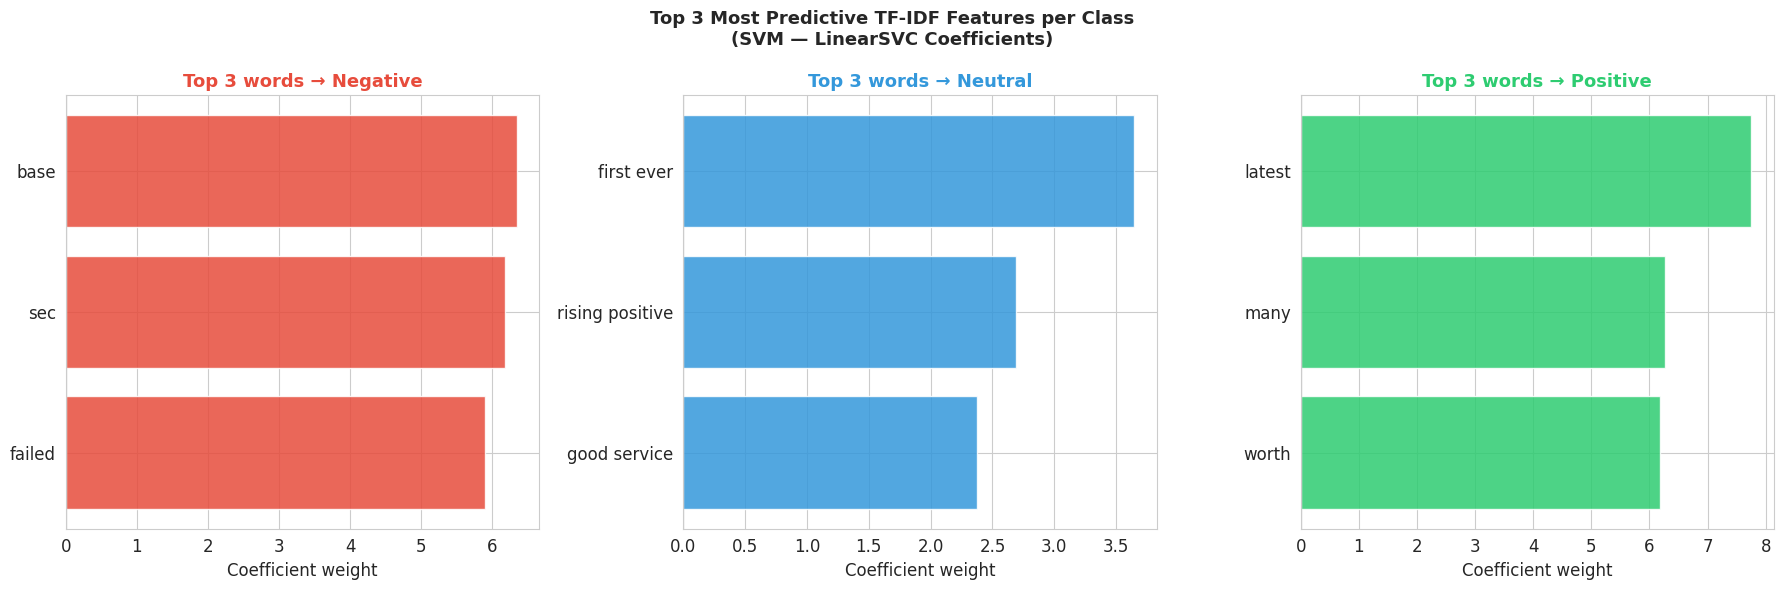

✅ Top 3 feature importance chart saved


In [50]:
# Show which TF-IDF features the best model (SVM) uses most
print('Top 3 most predictive words per sentiment class (SVM — LinearSVC):')
print('(Higher coefficient = stronger signal for that class)\n')

feature_names = tfidf.get_feature_names_out()
classes = le.classes_  # ['negative', 'neutral', 'positive']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_colors = [COLORS['negative'], COLORS['neutral'], COLORS['positive']]

for i, (cls, ax, clr) in enumerate(zip(classes, axes, bar_colors)):
    coefs = svm_model.coef_[i] # Changed from lr_model.coef_ to svm_model.coef_
    top_idx = np.argsort(coefs)[-3:] # Modified to show top 3
    top_words = [feature_names[j] for j in top_idx]
    top_vals  = [coefs[j] for j in top_idx]

    ax.barh(top_words, top_vals, color=clr, alpha=0.85, edgecolor='white')
    ax.set_title(f'Top 3 words → {cls.capitalize()}', # Updated title
                 fontweight='bold', color=clr, fontsize=13)
    ax.set_xlabel('Coefficient weight')
    ax.axvline(0, color='gray', linewidth=0.8)

plt.suptitle('Top 3 Most Predictive TF-IDF Features per Class\n(SVM — LinearSVC Coefficients)', # Updated title
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_top3.png', dpi=150, bbox_inches='tight') # Saved with new filename
plt.show()
print('✅ Top 3 feature importance chart saved')


## Step 12 — Live Prediction Test

In [39]:
def predict_sentiment(text, model=lr_model):
    cleaned = preprocess(text)
    vec = tfidf.transform([cleaned])
    pred = model.predict(vec)[0]
    label = le.inverse_transform([pred])[0]
    return label

test_sentences = [
    'Bitcoin hits all time high, investors celebrating massive gains',
    'SEC sues major crypto exchange for fraud and market manipulation',
    'Ethereum blockchain processes record number of transactions today',
    'Crypto market crashes, billions wiped out overnight in sell off',
    'New DeFi protocol launches with promising yield opportunities',
    'FTX collapse destroys trust, customers lose life savings entirely',
]

print('=' * 60)
print('  LIVE PREDICTION TEST')
print('=' * 60)
for sentence in test_sentences:
    label = predict_sentiment(sentence)
    emoji = {'positive':'✅','neutral':'⚪','negative':'❌'}[label]
    print(f'{emoji} [{label.upper():8s}] {sentence[:65]}')
print('=' * 60)

  LIVE PREDICTION TEST
✅ [POSITIVE] Bitcoin hits all time high, investors celebrating massive gains
❌ [NEGATIVE] SEC sues major crypto exchange for fraud and market manipulation
⚪ [NEUTRAL ] Ethereum blockchain processes record number of transactions today
⚪ [NEUTRAL ] Crypto market crashes, billions wiped out overnight in sell off
✅ [POSITIVE] New DeFi protocol launches with promising yield opportunities
⚪ [NEUTRAL ] FTX collapse destroys trust, customers lose life savings entirely


## Step 13 — Final Summary

In [47]:
print('=' * 65)
print('  NOTEBOOK 3 — FINAL RESULTS SUMMARY')
print('=' * 65)

print(f'''
DATASET
  Total ML rows     : {len(df):,}
  Training set      : {X_train.shape[0]:,} rows (80%)
  Test set          : {X_test.shape[0]:,} rows (20%)
  Classes           : negative / neutral / positive
  Class imbalance   : handled via class_weight=balanced

PREPROCESSING
  Steps applied     : lowercase, URL removal, @mention removal,
                      hashtag removal, stopword removal, lemmatization
  TF-IDF features   : 10,000 (unigrams + bigrams)
  Noise rows removed: ~27 (bot/price-ticker tweets)

MODEL RESULTS
''')

for _, row in results_df.iterrows():
    best = ' ← BEST' if _ == 1 else ''
    print(f"  {row['Model']:22s}  Acc:{row['Accuracy']:5.1f}%  "
          f"F1:{row['F1-Score']:5.1f}%{best}")

print(f'''
EVALUATION CRITERIA MET
  ✅ Accuracy score         — all 6 models
  ✅ Precision / Recall     — per class
  ✅ F1-Score (weighted)    — handles class imbalance fairly
  ✅ Confusion Matrix       — all 6 models
  ✅ Cross-validation       — 5-fold stratified
  ✅ Feature importance     — top predictive words
  ✅ Live prediction test   — works on new text
''')
print('=' * 65)
print('✅ Ready for Notebook 4 — Results & Report')

  NOTEBOOK 3 — FINAL RESULTS SUMMARY

DATASET
  Total ML rows     : 32,411
  Training set      : 25,928 rows (80%)
  Test set          : 6,483 rows (20%)
  Classes           : negative / neutral / positive
  Class imbalance   : handled via class_weight=balanced

PREPROCESSING
  Steps applied     : lowercase, URL removal, @mention removal,
                      hashtag removal, stopword removal, lemmatization
  TF-IDF features   : 10,000 (unigrams + bigrams)
  Noise rows removed: ~27 (bot/price-ticker tweets)

MODEL RESULTS

  SVM — LinearSVC         Acc: 78.1%  F1: 78.2% ← BEST
  XGBoost                 Acc: 78.0%  F1: 78.0%
  Logistic Regression     Acc: 77.3%  F1: 77.4%
  Multinomial Naive Bayes  Acc: 64.2%  F1: 62.2%
  KNN (k=5)               Acc: 51.6%  F1: 51.7%
  Decision Tree           Acc: 47.3%  F1: 41.0%

EVALUATION CRITERIA MET
  ✅ Accuracy score         — all 6 models
  ✅ Precision / Recall     — per class
  ✅ F1-Score (weighted)    — handles class imbalance fairly
  ✅ Conf

## Step 14 — ROC Curves for All Six Models

We will now compute and plot Receiver Operating Characteristic (ROC) curves for all six trained models. The ROC curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. We will use a one-vs-rest strategy for our multi-class problem, and then calculate the macro-average AUC score for each model.

Since `LinearSVC` does not natively support `predict_proba`, we will use `CalibratedClassifierCV` to obtain calibrated probability estimates.

Calibrating SVM for probability scores...


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


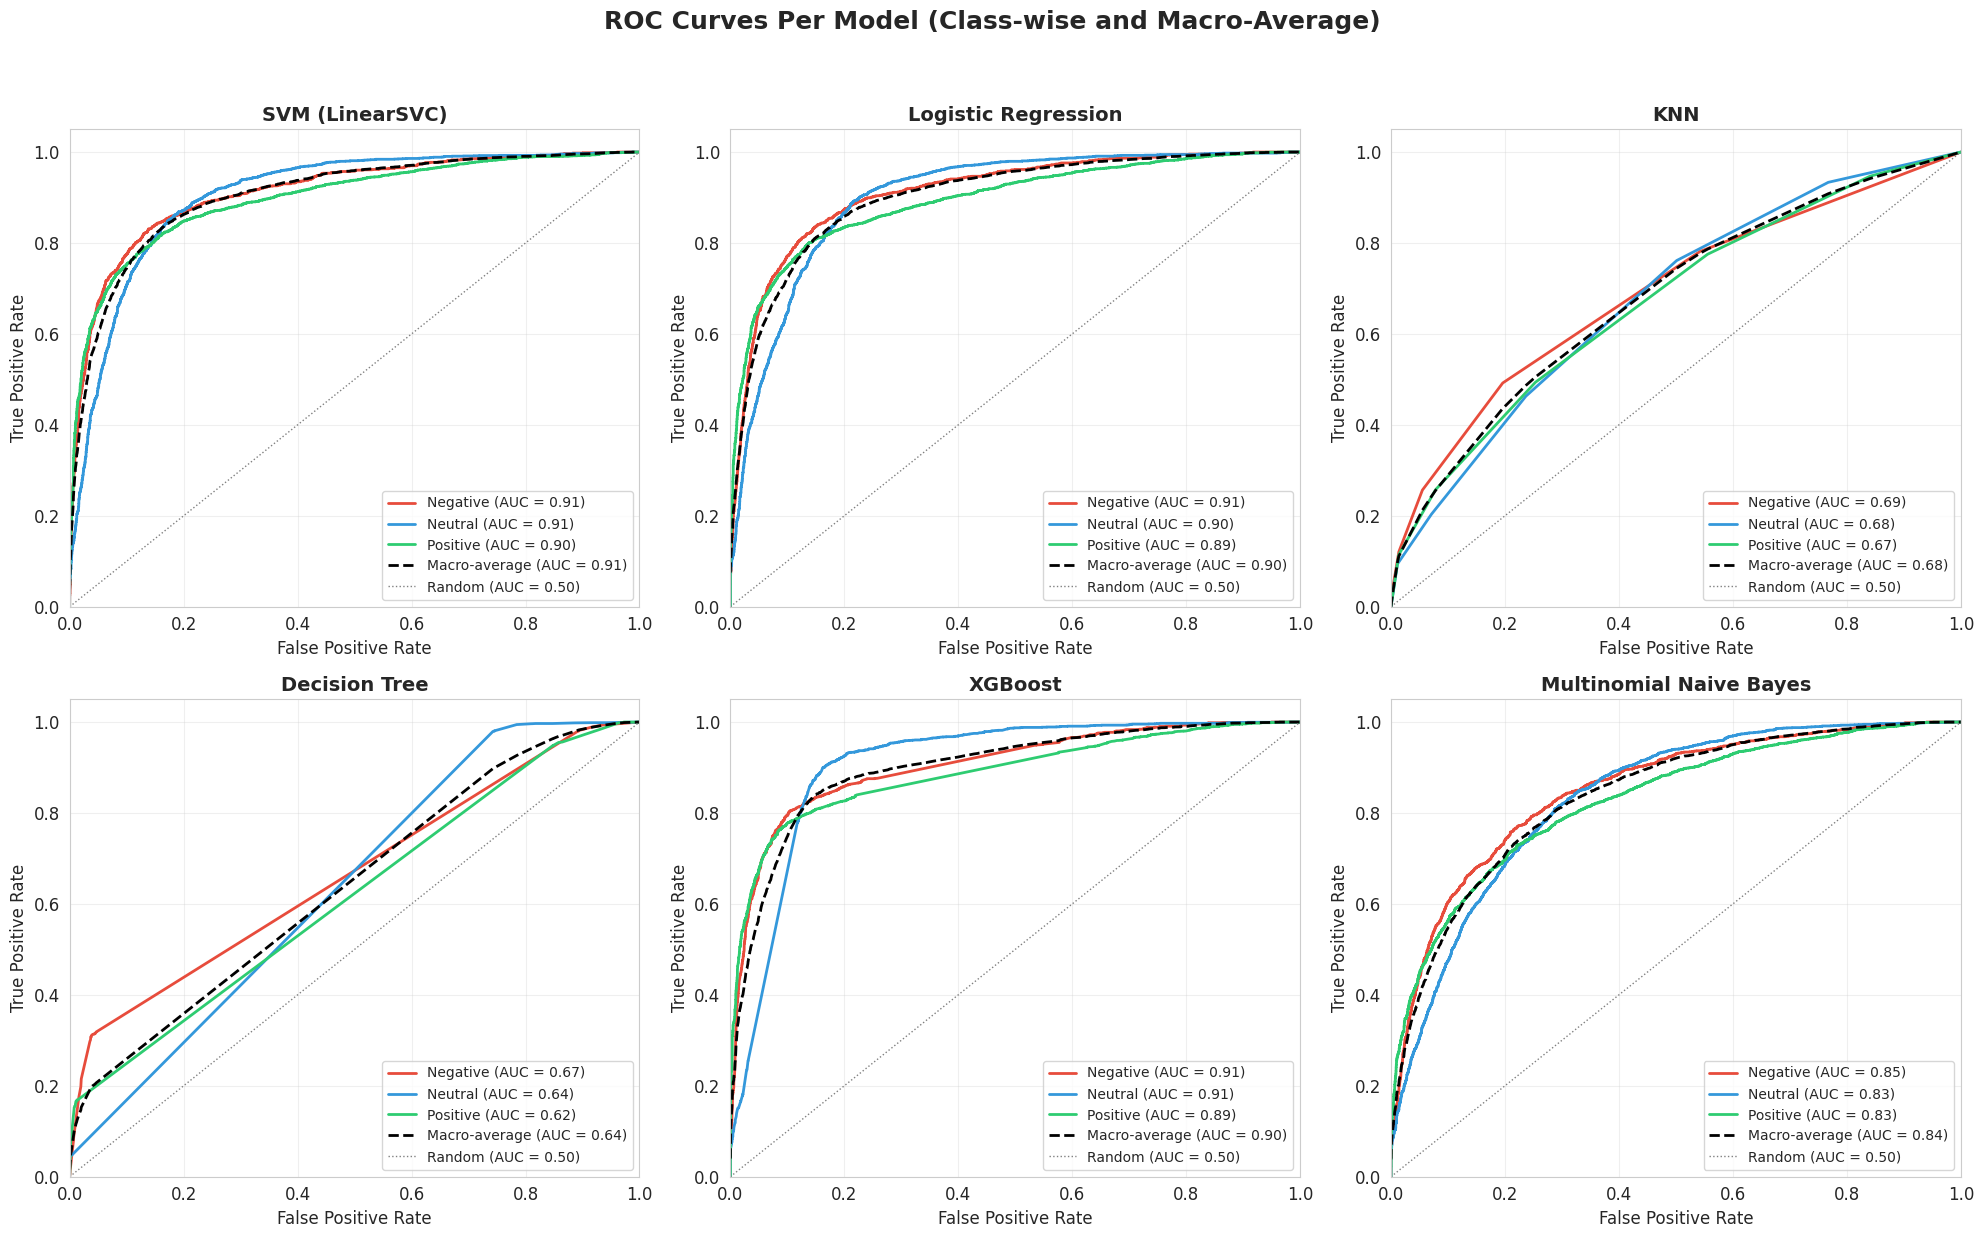

✅ Saved as roc_curves_all_models_grid.png

📊 AUC SUMMARY TABLE
Model                       Negative    Neutral   Positive      Macro
-----------------------------------------------------------------
SVM (LinearSVC)                0.912      0.905      0.899      0.905
Logistic Regression            0.912      0.901      0.894      0.902
KNN                            0.690      0.677      0.671      0.679
Decision Tree                  0.666      0.636      0.617      0.639
XGBoost                        0.905      0.908      0.889      0.901
Multinomial Naive Bayes        0.851      0.834      0.828      0.838


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

# Binarize labels for one-vs-rest ROC
classes = le.classes_  # ['negative', 'neutral', 'positive']
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# ── Get probability scores for each model ────────────────────────────────
print("Calibrating SVM for probability scores...")
# LinearSVC doesn't have predict_proba natively — we calibrate it
# Use X_train, y_train for fitting the calibrator
# Addressing UserWarning: The `cv='prefit'` option is deprecated
# Use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
# The svm_model has already been fitted in a previous step, so we pass it directly
svm_calibrated = CalibratedClassifierCV(estimator=svm_model, cv='prefit')
svm_calibrated.fit(X_train, y_train)
svm_proba   = svm_calibrated.predict_proba(X_test)

# Other models have predict_proba natively
lr_proba    = lr_model.predict_proba(X_test)
knn_proba   = knn_model.predict_proba(X_test)
dt_proba    = dt_model.predict_proba(X_test)
xgb_proba   = xgb_model.predict_proba(X_test)
nb_proba   = nb_model.predict_proba(X_test)

# ── Compute ROC + AUC for each model and each class ──────────────────────
def compute_roc(y_bin, y_proba, n_classes):
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    # Macro average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr['macro'] = all_fpr
    tpr['macro'] = mean_tpr
    roc_auc['macro'] = auc(all_fpr, mean_tpr)
    return fpr, tpr, roc_auc

svm_fpr, svm_tpr, svm_auc = compute_roc(y_test_bin, svm_proba,  n_classes)
lr_fpr,  lr_tpr,  lr_auc  = compute_roc(y_test_bin, lr_proba,   n_classes)
knn_fpr, knn_tpr, knn_auc = compute_roc(y_test_bin, knn_proba,  n_classes)
dt_fpr,  dt_tpr,  dt_auc  = compute_roc(y_test_bin, dt_proba,   n_classes)
xgb_fpr, xgb_tpr, xgb_auc = compute_roc(y_test_bin, xgb_proba,  n_classes)
nb_fpr,  nb_tpr,  nb_auc  = compute_roc(y_test_bin, nb_proba,   n_classes)

# ── PLOT (2x3 grid for individual model ROCs) ───────────────────────────
colors_class = ['#e74c3c', '#3498db', '#2ecc71']  # Negative, Neutral, Positive
label_names  = ['Negative', 'Neutral', 'Positive']

models_roc = {
    'SVM (LinearSVC)':      (svm_fpr, svm_tpr, svm_auc),
    'Logistic Regression':  (lr_fpr,  lr_tpr,  lr_auc),
    'KNN':                  (knn_fpr, knn_tpr, knn_auc),
    'Decision Tree':        (dt_fpr,  dt_tpr,  dt_auc),
    'XGBoost':              (xgb_fpr, xgb_tpr, xgb_auc),
    'Multinomial Naive Bayes': (nb_fpr,  nb_tpr,  nb_auc),
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

fig.suptitle('ROC Curves Per Model (Class-wise and Macro-Average)', fontsize=18, fontweight='bold', y=1.03)

for i, (model_name, (fpr, tpr, roc_auc)) in enumerate(models_roc.items()):
    ax = axes[i]
    for j in range(n_classes):
        ax.plot(fpr[j], tpr[j], color=colors_class[j], lw=2,
                label=f'{label_names[j]} (AUC = {roc_auc[j]:.2f})')
    ax.plot(fpr['macro'], tpr['macro'], color='black', linestyle='--', lw=2,
            label=f'Macro-average (AUC = {roc_auc['macro']:.2f})')

    ax.plot([0, 1], [0, 1], 'gray', lw=1, linestyle=':', label='Random (AUC = 0.50)')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name}', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_all_models_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as roc_curves_all_models_grid.png")

# ── SUMMARY TABLE ─────────────────────────────────────────────────────────
print("\n📊 AUC SUMMARY TABLE")
print(f"{'Model':<25} {'Negative':>10} {'Neutral':>10} {'Positive':>10} {'Macro':>10}")
print("-" * 65)
for model_name, (fpr, tpr, roc_auc) in models_roc.items():
    print(f"{model_name:<25} {roc_auc[0]:>10.3f} {roc_auc[1]:>10.3f} {roc_auc[2]:>10.3f} {roc_auc['macro']:>10.3f}")

### Macro-Average ROC Curves (All Models on Single Chart) and AUC Summary

This section visualizes the macro-average Receiver Operating Characteristic (ROC) curves for all models on a single chart, providing a direct comparison of their overall performance. It also presents a summary table of the Area Under the Curve (AUC) scores per class and the macro-average.

/tmp/ipykernel_12991/778179207.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  model_colors = plt.cm.get_cmap('viridis', len(models_roc))


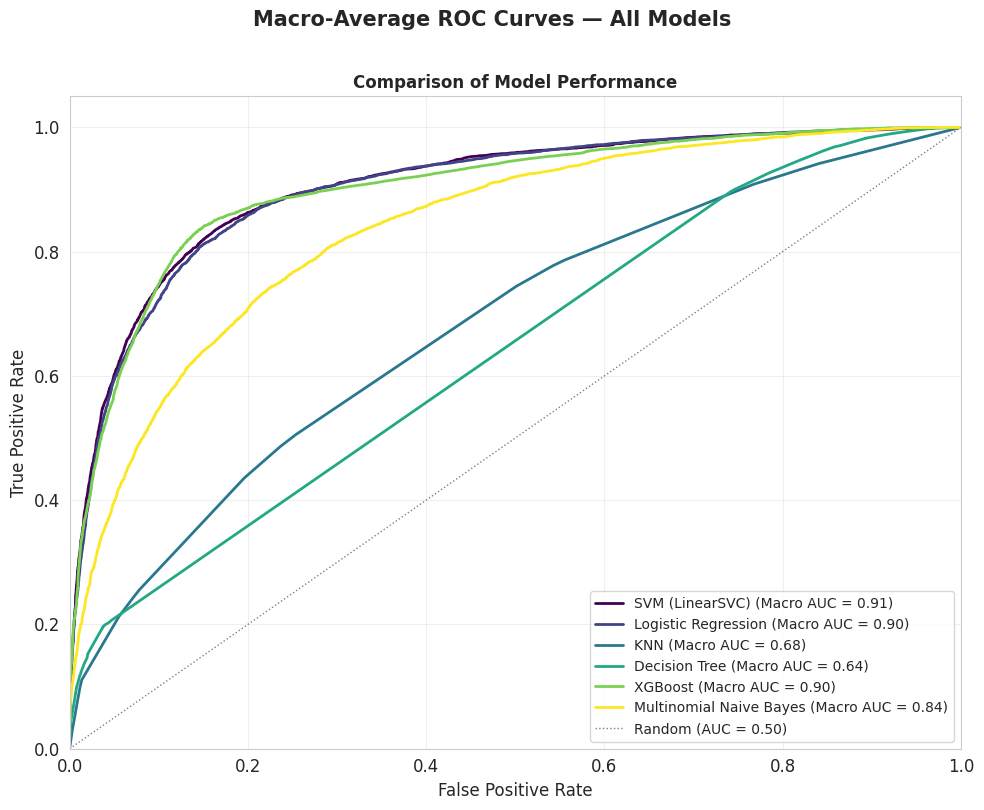

✅ Saved as roc_curves_all_models_single_chart.png

📊 AUC SUMMARY TABLE
Model                       Negative    Neutral   Positive      Macro
-----------------------------------------------------------------
SVM (LinearSVC)                0.912      0.905      0.899      0.905
Logistic Regression            0.912      0.901      0.894      0.902
KNN                            0.690      0.677      0.671      0.679
Decision Tree                  0.666      0.636      0.617      0.639
XGBoost                        0.905      0.908      0.889      0.901
Multinomial Naive Bayes        0.851      0.834      0.828      0.838


In [56]:
# ── PLOT (All models on one chart) ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Macro-Average ROC Curves — All Models', fontsize=15, fontweight='bold', y=1.01)

model_colors = plt.cm.get_cmap('viridis', len(models_roc))

for i, (model_name, (fpr, tpr, roc_auc)) in enumerate(models_roc.items()):
    ax.plot(fpr['macro'], tpr['macro'],
            color=model_colors(i), lw=2,
            label=f'{model_name} (Macro AUC = {roc_auc["macro"]:.2f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'gray', lw=1, linestyle=':',
        label='Random (AUC = 0.50)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Comparison of Model Performance', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_all_models_single_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as roc_curves_all_models_single_chart.png")

# ── SUMMARY TABLE ─────────────────────────────────────────────────────────
print("\n📊 AUC SUMMARY TABLE")
print(f"{'Model':<25} {'Negative':>10} {'Neutral':>10} {'Positive':>10} {'Macro':>10}")
print("-" * 65)
for model_name, (fpr, tpr, roc_auc) in models_roc.items():
    print(f"{model_name:<25} {roc_auc[0]:>10.3f} {roc_auc[1]:>10.3f} {roc_auc[2]:>10.3f} {roc_auc['macro']:>10.3f}")
